In [1]:
# ============================================================
# CUTTING LYNE FREIGHT & LOGISTICS — TECHNICAL ASSESSMENT
# TASK 1: CUSTOMS CLASSIFICATION MODEL
#
# Objective:
# Classify product/cargo descriptions into 6-digit HS codes.
#
# Approach:
#   1. Dataset audit
#   2. Data cleaning
#   3. HS-code normalization
#   4. Duplicate/ambiguity handling
#   5. TF-IDF feature extraction
#   6. Logistic Regression baseline
#   7. Linear SVM candidate
#   8. Model evaluation
#   9. Robustness testing
#  10. Save final model
# ============================================================

In [2]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

In [3]:
import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
import pandas as pd
df = pd.read_csv("dataset/hsclassify_micro_dataset.csv")

In [7]:
import os

DATA_DIR = "dataset"

csv_files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith(".csv")]
if not csv_files:
    raise FileNotFoundError("No CSV file found in the dataset folder.")

DATA_PATH = os.path.join(DATA_DIR, csv_files[0])
print("Dataset:", DATA_PATH)

Dataset: dataset\hsclassify_micro_dataset.csv


In [8]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

display(df.head())

Dataset loaded successfully.
Rows: 141,794
Columns: 8


,text,hs_code,hs_chapter,hs_chapter_code,hs_chapter_name,hs_desc,language,text_prefixed
0,"ketones; cyclanic, cyclenic or cycloterpenic, ...",291429,Organic chemicals,HS 29,Organic chemicals,"Ketones; cyclanic, cyclenic or cycloterpenic, ...",en,"passage: ketones; cyclanic, cyclenic or cyclot..."
1,meat and edible meat offal; of reptiles (inclu...,20850,Meat and edible meat offal,HS 02,Meat and edible meat offal,Meat and edible meat offal; of reptiles (inclu...,en,passage: meat and edible meat offal; of reptil...
2,"stone; monumental or building stone, n.e.c. in...",680229,"Stone, plaster, cement, asbestos, mica or simi...",HS 68,"Stone, plaster, cement, asbestos, mica or simi...","Stone; monumental or building stone, n.e.c. in...",en,"passage: stone; monumental or building stone, ..."
3,Hàng nhập khẩu: alkaloids; natural or reproduc...,293980,Organic chemicals,HS 29,Organic chemicals,"Alkaloids; natural or reproduced by synthesis,...",vi,passage: Hàng nhập khẩu: alkaloids; natural or...
4,cotton; waste other than garnetted stock and y...,520299,Cotton,HS 52,Cotton,Cotton; waste other than garnetted stock and y...,zh,passage: cotton; waste other than garnetted st...


In [9]:
print("Columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns:
1. text
2. hs_code
3. hs_chapter
4. hs_chapter_code
5. hs_chapter_name
6. hs_desc
7. language
8. text_prefixed


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 141794 entries, 0 to 141793
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   text             141794 non-null  str  
 1   hs_code          141794 non-null  int64
 2   hs_chapter       141794 non-null  str  
 3   hs_chapter_code  141794 non-null  str  
 4   hs_chapter_name  141794 non-null  str  
 5   hs_desc          141794 non-null  str  
 6   language         141794 non-null  str  
 7   text_prefixed    141794 non-null  str  
dtypes: int64(1), str(7)
memory usage: 8.7 MB


In [11]:
missing = df.isnull().sum()

missing_percentage = (
    missing / len(df) * 100
).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage
})

display(missing_report)

,missing_count,missing_percentage
text,0,0.0
hs_code,0,0.0
hs_chapter,0,0.0
hs_chapter_code,0,0.0
hs_chapter_name,0,0.0
hs_desc,0,0.0
language,0,0.0
text_prefixed,0,0.0


In [12]:
exact_duplicates = df.duplicated().sum()

duplicate_texts = df["text"].duplicated().sum()

print(f"Exact duplicate rows: {exact_duplicates:,}")
print(f"Duplicate text values: {duplicate_texts:,}")

Exact duplicate rows: 0
Duplicate text values: 2,108


In [13]:
language_counts = df["language"].value_counts()

display(language_counts.to_frame("records"))

,records
language,
en,73866
th,22684
zh,22638
vi,22606


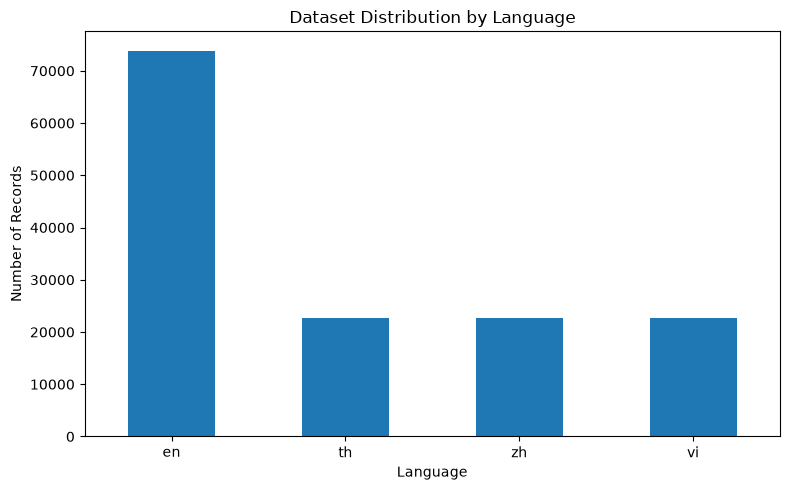

In [14]:
plt.figure(figsize=(8, 5))

language_counts.plot(kind="bar")

plt.title("Dataset Distribution by Language")
plt.xlabel("Language")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
print("HS code lengths BEFORE normalization:")

print(
    df["hs_code"]
    .astype(str)
    .str.len()
    .value_counts()
    .sort_index()
)

HS code lengths BEFORE normalization:
hs_code
5     12708
6    129086
Name: count, dtype: int64


In [16]:
df["hs_code"] = (
    df["hs_code"]
    .astype(str)
    .str.strip()
    .str.replace(".0", "", regex=False)
    .str.zfill(6)
)

In [17]:
print("HS code lengths AFTER normalization:")

print(
    df["hs_code"]
    .astype(str)
    .str.len()
    .value_counts()
    .sort_index()
)

HS code lengths AFTER normalization:
hs_code
6    141794
Name: count, dtype: int64


In [18]:
invalid_hs_codes = df[
    ~df["hs_code"].str.fullmatch(r"\d{6}", na=False)
]

print(
    f"Invalid six-digit HS codes: {len(invalid_hs_codes):,}"
)

if len(invalid_hs_codes) > 0:
    display(invalid_hs_codes.head())

Invalid six-digit HS codes: 0


In [19]:
hs_distribution = df["hs_code"].value_counts()

print(f"Unique HS codes: {df['hs_code'].nunique():,}")

print("\nMost common HS codes:")
display(hs_distribution.head(20).to_frame("records"))

Unique HS codes: 5,621

Most common HS codes:


,records
hs_code,
611020,504
611030,473
870323,473
848180,434
870332,395
392190,297
870324,249
870322,241
610230,222


In [20]:
class_stats = hs_distribution.describe()

display(class_stats)

count    5621.000000
mean       25.225761
std        18.387508
min        16.000000
25%        22.000000
50%        22.000000
75%        23.000000
max       504.000000
Name: count, dtype: float64

In [21]:
print("Minimum examples in a class:", hs_distribution.min())
print("Maximum examples in a class:", hs_distribution.max())
print("Median examples per class:", hs_distribution.median())
print("Mean examples per class:", round(hs_distribution.mean(), 2))

Minimum examples in a class: 16
Maximum examples in a class: 504
Median examples per class: 22.0
Mean examples per class: 25.23


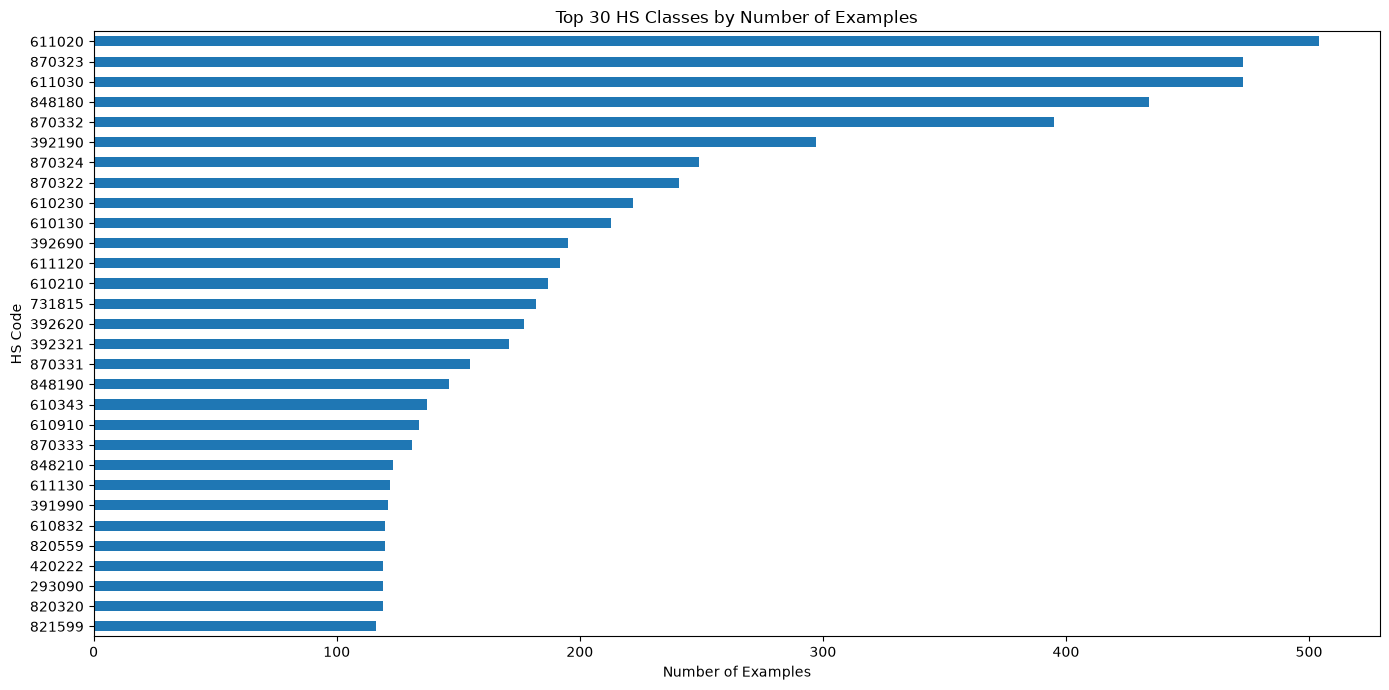

In [22]:
top_classes = hs_distribution.head(30)

plt.figure(figsize=(14, 7))

top_classes.sort_values().plot(kind="barh")

plt.title("Top 30 HS Classes by Number of Examples")
plt.xlabel("Number of Examples")
plt.ylabel("HS Code")

plt.tight_layout()
plt.show()

In [23]:
language_hs = df.groupby("language")["hs_code"].nunique()

display(
    language_hs.to_frame("unique_hs_codes")
)

,unique_hs_codes
language,
en,5621
th,5621
vi,5621
zh,5621


In [24]:
df["text_length"] = df["text"].astype(str).str.len()

print("Description length statistics:")

display(
    df["text_length"].describe()
)

Description length statistics:


count    141794.000000
mean        150.235370
std          72.081612
min           3.000000
25%          97.000000
50%         148.000000
75%         199.000000
max         400.000000
Name: text_length, dtype: float64

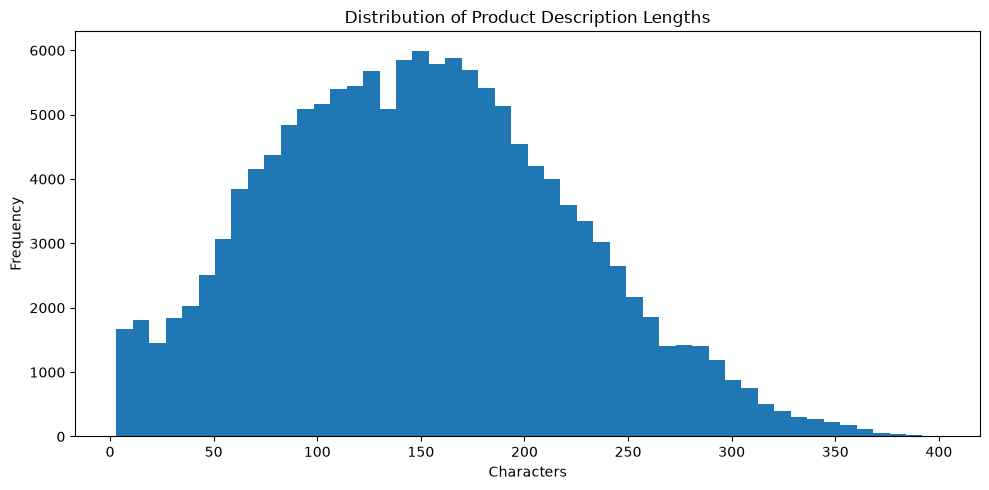

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["text_length"],
    bins=50
)

plt.title("Distribution of Product Description Lengths")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [26]:
pd.set_option("display.max_colwidth", 200)

display(
    df[
        ["text", "hs_code", "hs_desc", "language"]
    ].sample(
        20,
        random_state=RANDOM_STATE
    )
)

,text,hs_code,hs_desc,language
84626,"สินค้านำเข้า: ferrous products; obtained by direct reduction of iron ore, in lumps, pellets or similar forms สำหรับจำหน่ายเชิงพาณิชย์",720310,"Ferrous products; obtained by direct reduction of iron ore, in lumps, pellets or similar forms",th
48602,safety pins and other pins; of iron or steel คุณภาพส่งออก บรรจุหีบห่อมาตรฐาน สำหรับการขนส่งข้ามพรมแดน พร้อมใบกำกับสินค้าและบัญชีบรรจุหีบห่อ,731940,Safety pins and other pins; of iron or steel,th
40781,"ใบขนสินค้า: fruit, edible; guavas, mangoes and mangosteens, fresh or dried สินค้าใหม่ จำนวนตามใบสั่งซื้อ",080450,"Fruit, edible; guavas, mangoes and mangosteens, fresh or dried",th
61872,"Tờ khai hải quan: wrist-watches; (not electrically operated), (not automatic winding), whether or not incorporating a stop-watch facility, case of precious metal or of metal clad with precious met...",910129,"Wrist-watches; (not electrically operated), (not automatic winding), whether or not incorporating a stop-watch facility, case of precious metal or of metal clad with precious metal",vi
131259,"ใบขนสินค้า: iron or non-alloy steel; flat-rolled, hot-rolled, rolled on four faces or in a closed box pass, of a width more than 150mm but less than 600mm, 4mm thick or more, not in coils, without...",721113,"Iron or non-alloy steel; flat-rolled, hot-rolled, rolled on four faces or in a closed box pass, of a width more than 150mm but less than 600mm, 4mm thick or more, not in coils, without patterns in...",th
100593,"regulating or controlling instruments and apparatus; automatic, manostats，出口品质，标准包装，交付至保税仓库，混合批次货物",903220,"Regulating or controlling instruments and apparatus; automatic, manostats",zh
130779,"Caterpillar — machinery; for manufacture or finishing felt or non-wovens in the piece or in shapes, including machinery for making felt hats, blocks for making hats, for commercial distribution, f...",844900,"Machinery; for manufacture or finishing felt or non-wovens in the piece or in shapes, including machinery for making felt hats, blocks for making hats",en
62911,"Supply of cyclic amides (including cyclic carbamates) and their derivatives; alachlor (iso) and its salts, ACS reagent grade, 200L HDPE drum, for customs clearance and import declaration, with sta...",292425,Cyclic amides (including cyclic carbamates) and their derivatives; alachlor (ISO) and its salts,en
96296,women's gardening gloves made of various materials,621600,"Gloves, mittens and mitts (not knitted or crocheted)",en
90283,"สินค้านำเข้า: halogenated olefin polymers; fluoro-polymers (other than polytetrafluoroethylene), in primary forms สำหรับจำหน่ายเชิงพาณิชย์ สำหรับห่วงโซ่อุปทานค้าปลีกในภูมิภาค เงื่อนไขการขนส่ง FOB",390469,"Halogenated olefin polymers; fluoro-polymers (other than polytetrafluoroethylene), in primary forms",th


In [27]:
comparison = (
    df["text_prefixed"]
    .astype(str)
    .str.replace(
        r"^passage:\s*",
        "",
        regex=True
    )
)

same_as_text = (
    comparison.str.strip() ==
    df["text"].astype(str).str.strip()
)

print(
    "text_prefixed contains the same description:",
    same_as_text.mean() * 100,
    "%"
)

text_prefixed contains the same description: 100.0 %


In [28]:
english_df = df[
    df["language"].astype(str).str.lower().eq("en")
].copy()

print(
    f"English records: {len(english_df):,}"
)

print(
    f"Unique English HS codes: "
    f"{english_df['hs_code'].nunique():,}"
)

English records: 73,866
Unique English HS codes: 5,621


In [29]:
def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower().strip()

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text


english_df["text_clean"] = (
    english_df["text"]
    .apply(clean_text)
)

english_df.head()

,text,hs_code,hs_chapter,hs_chapter_code,hs_chapter_name,hs_desc,language,text_prefixed,text_length,text_clean
0,"ketones; cyclanic, cyclenic or cycloterpenic, without other oxygen function, other than cyclohexanone, methylcyclohexanones, ionones, and methylionones, 25kg fiber drum, SDS included, industrial g...",291429,Organic chemicals,HS 29,Organic chemicals,"Ketones; cyclanic, cyclenic or cycloterpenic, without other oxygen function, other than cyclohexanone, methylcyclohexanones, ionones, and methylionones",en,"passage: ketones; cyclanic, cyclenic or cycloterpenic, without other oxygen function, other than cyclohexanone, methylcyclohexanones, ionones, and methylionones, 25kg fiber drum, SDS included, ind...",251,"ketones; cyclanic, cyclenic or cycloterpenic, without other oxygen function, other than cyclohexanone, methylcyclohexanones, ionones, and methylionones, 25kg fiber drum, sds included, industrial g..."
1,"meat and edible meat offal; of reptiles (including snakes and turtles), fresh, chilled or frozen, sourced from certified farms, blast frozen, for international wholesale distribution, shipping ter...",020850,Meat and edible meat offal,HS 02,Meat and edible meat offal,"Meat and edible meat offal; of reptiles (including snakes and turtles), fresh, chilled or frozen",en,"passage: meat and edible meat offal; of reptiles (including snakes and turtles), fresh, chilled or frozen, sourced from certified farms, blast frozen, for international wholesale distribution, shi...",201,"meat and edible meat offal; of reptiles (including snakes and turtles), fresh, chilled or frozen, sourced from certified farms, blast frozen, for international wholesale distribution, shipping ter..."
2,"stone; monumental or building stone, n.e.c. in item no. 6802.2, articles thereof, simply cut or sawn, with a flat or even surface, borosilicate, laboratory grade, in crates",680229,"Stone, plaster, cement, asbestos, mica or similar materials; articles thereof",HS 68,"Stone, plaster, cement, asbestos, mica or similar materials; articles thereof","Stone; monumental or building stone, n.e.c. in item no. 6802.2, articles thereof, simply cut or sawn, with a flat or even surface",en,"passage: stone; monumental or building stone, n.e.c. in item no. 6802.2, articles thereof, simply cut or sawn, with a flat or even surface, borosilicate, laboratory grade, in crates",172,"stone; monumental or building stone, n.e.c. in item no. 6802.2, articles thereof, simply cut or sawn, with a flat or even surface, borosilicate, laboratory grade, in crates"
5,Poly Bd R-20LM butadiene rubber,400220,Rubber and articles thereof,HS 40,Rubber and articles thereof,"Rubber; synthetic, butadiene rubber (BR), in primary forms or in plates, sheets or strip",en,passage: Poly Bd R-20LM butadiene rubber,31,poly bd r-20lm butadiene rubber
6,"fibres; synthetic staple fibres, of synthetic materials n.e.c. in heading no. 5503, not carded, combed or otherwise processed for spinning, 100% acrylic, width 150cm, roll of 100m, for bulk procur...",550390,Man-made staple fibres,HS 55,Man-made staple fibres,"Fibres; synthetic staple fibres, of synthetic materials n.e.c. in heading no. 5503, not carded, combed or otherwise processed for spinning",en,"passage: fibres; synthetic staple fibres, of synthetic materials n.e.c. in heading no. 5503, not carded, combed or otherwise processed for spinning, 100% acrylic, width 150cm, roll of 100m, for bu...",228,"fibres; synthetic staple fibres, of synthetic materials n.e.c. in heading no. 5503, not carded, combed or otherwise processed for spinning, 100% acrylic, width 150cm, roll of 100m, for bulk procur..."


In [30]:
before = len(english_df)

english_df = english_df[
    english_df["text_clean"].str.len() > 0
].copy()

after = len(english_df)

print(f"Removed empty descriptions: {before - after:,}")
print(f"Remaining records: {after:,}")

Removed empty descriptions: 0
Remaining records: 73,866


In [31]:
description_label_counts = (
    english_df
    .groupby("text_clean")["hs_code"]
    .nunique()
)

ambiguous_descriptions = set(
    description_label_counts[
        description_label_counts > 1
    ].index
)

print(
    f"Ambiguous descriptions: "
    f"{len(ambiguous_descriptions):,}"
)

Ambiguous descriptions: 1,052


In [32]:
ambiguous_examples = english_df[
    english_df["text_clean"].isin(
        ambiguous_descriptions
    )
]

display(
    ambiguous_examples[
        ["text", "hs_code", "hs_desc"]
    ].head(30)
)

,text,hs_code,hs_desc
7,"sledge hammers, hammers, picks, mattocks, and axes from China",820559,"Tools, hand; other hand tools (including glaziers diamonds), excluding household tools, drilling, threading or tapping tools, hammers and sledge hammers, planes, chisels, gouges and similar cuttin..."
56,Mercedes GLAClass,870332,"Vehicles; with only compression-ignition internal combustion piston engine (diesel or semi-diesel), cylinder capacity over 1500 but not over 2500cc"
108,Chevrolet Korea Cruze,870323,"Vehicles; with only spark-ignition internal combustion reciprocating piston engine, cylinder capacity over 1500 but not over 3000cc"
113,root_word,741121,"Copper; tubes and pipes, of copper-zinc base alloys (brass)"
168,Volkswagen Golf,870321,"Vehicles; with only spark-ignition internal combustion piston engine, cylinder capacity not over 1000cc"
170,Chevrolet Korea Captiva,870324,"Vehicles; with only spark-ignition internal combustion reciprocating piston engine, cylinder capacity over 3000cc"
260,Hyundai Equus,870323,"Vehicles; with only spark-ignition internal combustion reciprocating piston engine, cylinder capacity over 1500 but not over 3000cc"
325,pedestal,901841,"Dental instruments and appliances; dental drill engines, whether or not combined on a single base with other dental equipment"
487,disposable fleece covers for the Danniflex (CPM 460) machine,630790,"Textiles; made up articles (including dress patterns), n.e.c. in chapter 63, n.e.c. in heading no. 6307"
543,Mini Cabrio,870331,"Vehicles; with only compression-ignition internal combustion piston engine (diesel or semi-diesel), cylinder capacity not over 1500cc"


In [33]:
model_df = english_df[
    ~english_df["text_clean"].isin(
        ambiguous_descriptions
    )
].copy()

In [34]:
before = len(model_df)

model_df = model_df.drop_duplicates(
    subset=["text_clean"]
)

after = len(model_df)

print(
    f"Duplicate descriptions removed: "
    f"{before - after:,}"
)

print(
    f"Final modelling records: {after:,}"
)

print(
    f"Final HS classes: "
    f"{model_df['hs_code'].nunique():,}"
)

Duplicate descriptions removed: 0
Final modelling records: 70,716
Final HS classes: 5,621


In [35]:
final_class_distribution = (
    model_df["hs_code"]
    .value_counts()
)

print(
    "Examples per class:"
)

print(
    final_class_distribution.describe()
)

Examples per class:
count    5621.000000
mean       12.580680
std        15.291385
min         4.000000
25%        10.000000
50%        10.000000
75%        11.000000
max       490.000000
Name: count, dtype: float64


In [36]:
low_support = (
    final_class_distribution[
        final_class_distribution < 20
    ]
)

print(
    f"Classes with fewer than 20 examples: "
    f"{len(low_support):,}"
)

display(
    low_support.head(30).to_frame("records")
)

Classes with fewer than 20 examples: 5,144


,records
hs_code,
853610,19
850490,19
852589,19
840310,19
841350,19
290110,19
400300,19
760612,19
722990,19


In [37]:
X = model_df["text_clean"]
y = model_df["hs_code"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70716,)
y shape: (70716,)


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training records: {len(X_train):,}")
print(f"Testing records:  {len(X_test):,}")

Training records: 56,572
Testing records:  14,144


In [39]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
    max_features=150_000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (56572, 64503)
Testing TF-IDF shape: (14144, 64503)


In [40]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss="log_loss",
    max_iter=30,
    tol=1e-3,
    alpha=1e-5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Training SGD baseline...")

sgd_model.fit(
    X_train_tfidf,
    y_train
)

print("SGD baseline trained successfully.")

Training SGD baseline...
SGD baseline trained successfully.


In [41]:
sgd_predictions = sgd_model.predict(
    X_test_tfidf
)

print("Predictions generated.")

Predictions generated.


In [42]:
sgd_accuracy = accuracy_score(
    y_test,
    sgd_predictions
)

sgd_macro_f1 = f1_score(
    y_test,
    sgd_predictions,
    average="macro",
    zero_division=0
)

sgd_weighted_f1 = f1_score(
    y_test,
    sgd_predictions,
    average="weighted",
    zero_division=0
)

print("SGD BASELINE")
print("=" * 40)
print(f"Accuracy:    {sgd_accuracy:.4f}")
print(f"Macro F1:    {sgd_macro_f1:.4f}")
print(f"Weighted F1: {sgd_weighted_f1:.4f}")

SGD BASELINE
Accuracy:    0.8368
Macro F1:    0.9017
Weighted F1: 0.8401


In [43]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

print("Training Linear SVM...")

svm_model.fit(
    X_train_tfidf,
    y_train
)

print("Linear SVM trained successfully.")

Training Linear SVM...
Linear SVM trained successfully.


In [44]:
svm_predictions = svm_model.predict(
    X_test_tfidf
)

print("SVM predictions generated.")

SVM predictions generated.


In [45]:
svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_macro_f1 = f1_score(
    y_test,
    svm_predictions,
    average="macro",
    zero_division=0
)

svm_weighted_f1 = f1_score(
    y_test,
    svm_predictions,
    average="weighted",
    zero_division=0
)

print("LINEAR SVM")
print("=" * 40)
print(f"Accuracy:    {svm_accuracy:.4f}")
print(f"Macro F1:    {svm_macro_f1:.4f}")
print(f"Weighted F1: {svm_weighted_f1:.4f}")

LINEAR SVM
Accuracy:    0.8731
Macro F1:    0.9271
Weighted F1: 0.8681


In [46]:
results = pd.DataFrame({
    "Model": [
        "SGD Classifier",
        "Linear SVM"
    ],
    "Accuracy": [
        sgd_accuracy,
        svm_accuracy
    ],
    "Macro F1": [
        sgd_macro_f1,
        svm_macro_f1
    ],
    "Weighted F1": [
        sgd_weighted_f1,
        svm_weighted_f1
    ]
})

display(
    results.sort_values(
        "Macro F1",
        ascending=False
    )
)

,Model,Accuracy,Macro F1,Weighted F1
1,Linear SVM,0.873091,0.927132,0.868078
0,SGD Classifier,0.836821,0.901712,0.840090


In [47]:
# ============================================================
# TOP-K ACCURACY
# ============================================================

svm_scores = svm_model.decision_function(X_test_tfidf)

class_labels = svm_model.classes_

top3_accuracy = top_k_accuracy_score(
    y_test,
    svm_scores,
    k=3,
    labels=class_labels
)

top5_accuracy = top_k_accuracy_score(
    y_test,
    svm_scores,
    k=5,
    labels=class_labels
)

print("=" * 50)
print("LINEAR SVM TOP-K PERFORMANCE")
print("=" * 50)

print(f"Top-1 Accuracy: {svm_accuracy:.4f}")
print(f"Top-3 Accuracy: {top3_accuracy:.4f}")
print(f"Top-5 Accuracy: {top5_accuracy:.4f}")

LINEAR SVM TOP-K PERFORMANCE
Top-1 Accuracy: 0.8731
Top-3 Accuracy: 0.9073
Top-5 Accuracy: 0.9196


In [48]:
prediction_results = pd.DataFrame({
    "description": X_test.values,
    "actual_hs_code": y_test.values,
    "predicted_hs_code": svm_predictions
})

prediction_results["correct"] = (
    prediction_results["actual_hs_code"]
    ==
    prediction_results["predicted_hs_code"]
)

print(
    f"Correct predictions: "
    f"{prediction_results['correct'].sum():,}"
)

print(
    f"Incorrect predictions: "
    f"{(~prediction_results['correct']).sum():,}"
)

display(
    prediction_results.head(20)
)

Correct predictions: 12,349
Incorrect predictions: 1,795


,description,actual_hs_code,predicted_hs_code,correct
0,"yarn; (not sewing thread), of artificial staple fibres, mixed mainly or solely with cotton, not put up for retail sale, egyptian cotton, 200 thread count, bleached",551030,551030,True
1,"dow chemical chemical products, mixtures and preparations; containing goods specified in subheading note 3 to this chapter; containing perfluorooctane sulphonic acid, its salts, perfluorooctane su...",382487,382487,True
2,"lot of 500 pcs: camping goods; pneumatic mattresses, assorted composition, assorted colours",630640,630640,True
3,"pepper, neither crushed nor ground for industrial/commercial use, for cross-border shipment, shipping term cif",090411,090411,True
4,"dmg mori — liquid elevators; parts thereof, for commercial distribution, for customs clearance and import declaration, for 20ft container loading",841392,841392,True
5,"seeds of herbaceous plants; cultivated principally for their flowers, of a kind used for sowing, freshly harvested, 50kg jute bags, export grade",120930,120930,True
6,"commercial order: mathematical equipment; micrometers, callipers and gauges, siemens healthineers, 10 units",901730,901730,True
7,fiat talento,870332,851711,False
8,"machinery and mechanical appliances; presses for the manufacture of particle or fibre building board of wood or other ligneous materials and other machinery for treating wood or cork, siemens bran...",847930,847930,True
9,"halal certified crustaceans; live, fresh or chilled, lobsters (homarus spp.), whether in shell or not, shrink-wrapped, for bulk procurement program, palletized for container shipment",030632,030632,True


In [49]:
errors = prediction_results[
    ~prediction_results["correct"]
].copy()

print(
    f"Total errors: {len(errors):,}"
)

display(
    errors.head(30)
)

Total errors: 1,795


,description,actual_hs_code,predicted_hs_code,correct
7,fiat talento,870332,851711,False
10,"hand-knitted persimmon pendant diy crochet bag keychain ornament semi-finished knitted fruit decorative accessory, origin: mainland china",630790,722490,False
16,"gas monitoring units including oxyclip, toxyclip, packrat, alarm rat, and plant rat",350510,902710,False
23,"a plastic baby bottle, 3-in-1 starter pack, and accessory pack from china",392690,901831,False
27,camlock fittings and rubber sheets from china,392620,741220,False
35,"a massage chair with built-in heating and massage components, upholstered in polyurethane, designed for personal use and comfort",940171,901910,False
39,"doming decals made of plastic, designed for rigorous applications such as on agricultural, construction, transportation, and outdoor power equipment",391990,401170,False
43,"analytical instruments used for chemical analysis, including the high toc multipurpose analyzer and the vario el analyzer",902730,902750,False
48,a rubber acoustic membrane used in the installation of ceramic tile floors,400300,392049,False
68,a cleaning machine for tray evaporators designed to clean aluminum evaporators using spray gun appliances,842430,330620,False


In [50]:
error_pairs = (
    errors
    .groupby(
        ["actual_hs_code", "predicted_hs_code"]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

display(
    error_pairs.head(30)
)

,actual_hs_code,predicted_hs_code,count
674,720441,851711,8
679,721113,851711,7
477,610230,610130,6
89,291891,851711,6
550,611020,611120,5
14,251612,851711,5
968,841459,841451,5
223,391731,851711,5
829,810295,851711,5
1434,871496,851711,5


In [51]:
for _, row in errors.head(20).iterrows():

    print("=" * 90)
    print("DESCRIPTION:")
    print(row["description"])
    print()
    print("ACTUAL HS CODE:   ", row["actual_hs_code"])
    print("PREDICTED HS CODE:", row["predicted_hs_code"])

DESCRIPTION:
fiat talento

ACTUAL HS CODE:    870332
PREDICTED HS CODE: 851711
DESCRIPTION:
hand-knitted persimmon pendant diy crochet bag keychain ornament semi-finished knitted fruit decorative accessory, origin: mainland china

ACTUAL HS CODE:    630790
PREDICTED HS CODE: 722490
DESCRIPTION:
gas monitoring units including oxyclip, toxyclip, packrat, alarm rat, and plant rat

ACTUAL HS CODE:    350510
PREDICTED HS CODE: 902710
DESCRIPTION:
a plastic baby bottle, 3-in-1 starter pack, and accessory pack from china

ACTUAL HS CODE:    392690
PREDICTED HS CODE: 901831
DESCRIPTION:
camlock fittings and rubber sheets from china

ACTUAL HS CODE:    392620
PREDICTED HS CODE: 741220
DESCRIPTION:
a massage chair with built-in heating and massage components, upholstered in polyurethane, designed for personal use and comfort

ACTUAL HS CODE:    940171
PREDICTED HS CODE: 901910
DESCRIPTION:
doming decals made of plastic, designed for rigorous applications such as on agricultural, construction, tr

In [52]:
def get_top_predictions(
    description,
    vectorizer,
    model,
    top_k=3
):
    """
    Return the top-k HS-code candidates ranked by
    the Linear SVM decision score.
    """

    cleaned = clean_text(description)

    X_input = vectorizer.transform(
        [cleaned]
    )

    scores = model.decision_function(
        X_input
    )

    if scores.ndim > 1:
        scores = scores[0]

    indices = np.argsort(scores)[::-1][:top_k]

    results = []

    for index in indices:

        results.append({
            "hs_code": str(
                model.classes_[index]
            ),
            "decision_score": float(
                scores[index]
            )
        })

    return results

In [53]:
GENERIC_TERMS = {
    "goods",
    "product",
    "products",
    "item",
    "items",
    "machine",
    "machinery",
    "parts",
    "part",
    "equipment"
}


def validate_description(description):

    text = str(
        description or ""
    ).strip().lower()

    flags = []

    if len(text) < 8:

        flags.append(
            "Insufficient product description"
        )

    words = text.split()

    if len(words) < 3:

        flags.append(
            "Description may be too general"
        )

    if text in GENERIC_TERMS:

        flags.append(
            "Description is too generic"
        )

    return flags

In [54]:
def classify_product(
    description,
    vectorizer,
    model,
    top_k=3
):

    validation_flags = validate_description(
        description
    )

    if validation_flags:

        return {
            "hs_code": None,
            "status": "manual_review",
            "risk_flags": validation_flags,
            "candidates": []
        }

    candidates = get_top_predictions(
        description,
        vectorizer,
        model,
        top_k=top_k
    )

    return {
        "hs_code": candidates[0]["hs_code"],
        "status": "classified",
        "risk_flags": [],
        "candidates": candidates
    }

In [55]:
test_descriptions = [
    "stainless steel automotive screw with washer",
    "cotton shirt",
    "pharmaceutical tablets",
    "air conditioning machine",
    "machine"
]

for description in test_descriptions:

    print("=" * 80)
    print("INPUT:", description)

    result = classify_product(
        description,
        vectorizer,
        svm_model
    )

    print(json.dumps(
        result,
        indent=4
    ))

INPUT: stainless steel automotive screw with washer
{
    "hs_code": "731815",
    "status": "classified",
    "risk_flags": [],
    "candidates": [
        {
            "hs_code": "731815",
            "decision_score": -0.6801218524764286
        },
        {
            "hs_code": "731814",
            "decision_score": -0.7518818222254209
        },
        {
            "hs_code": "731813",
            "decision_score": -0.870195986105041
        }
    ]
}
INPUT: cotton shirt
{
    "hs_code": null,
    "status": "manual_review",
    "risk_flags": [
        "Description may be too general"
    ],
    "candidates": []
}
INPUT: pharmaceutical tablets
{
    "hs_code": null,
    "status": "manual_review",
    "risk_flags": [
        "Description may be too general"
    ],
    "candidates": []
}
INPUT: air conditioning machine
{
    "hs_code": "841590",
    "status": "classified",
    "risk_flags": [],
    "candidates": [
        {
            "hs_code": "841590",
            "decision

In [56]:
hs_description_lookup = (
    df[
        ["hs_code", "hs_desc"]
    ]
    .dropna()
    .drop_duplicates(
        subset=["hs_code"]
    )
    .set_index("hs_code")["hs_desc"]
    .to_dict()
)

print(
    f"HS descriptions available for "
    f"{len(hs_description_lookup):,} codes."
)

HS descriptions available for 5,621 codes.


In [57]:
def classify_product_readable(
    description,
    vectorizer,
    model,
    top_k=3
):

    validation_flags = validate_description(
        description
    )

    if validation_flags:

        return {
            "input": description,
            "status": "manual_review",
            "hs_code": None,
            "description": None,
            "risk_flags": validation_flags,
            "alternatives": []
        }

    candidates = get_top_predictions(
        description,
        vectorizer,
        model,
        top_k
    )

    best_code = candidates[0]["hs_code"]

    alternatives = []

    for candidate in candidates[1:]:

        code = candidate["hs_code"]

        alternatives.append({
            "hs_code": code,
            "description": hs_description_lookup.get(
                code,
                "Description unavailable"
            ),
            "decision_score": round(
                candidate["decision_score"],
                4
            )
        })

    return {
        "input": description,
        "status": "classified",
        "hs_code": best_code,
        "description": hs_description_lookup.get(
            best_code,
            "Description unavailable"
        ),
        "risk_flags": [],
        "alternatives": alternatives
    }

In [58]:
result = classify_product_readable(
    "a stainless steel M5 x 0.8 automotive screw with washer",
    vectorizer,
    svm_model
)

print(
    json.dumps(
        result,
        indent=4
    )
)

{
    "input": "a stainless steel M5 x 0.8 automotive screw with washer",
    "status": "classified",
    "hs_code": "731815",
    "description": "Iron or steel; threaded screws and bolts n.e.c. in item no. 7318.1, whether or not with their nuts or washers",
    "risk_flags": [],
    "alternatives": [
        {
            "hs_code": "731814",
            "description": "Iron or steel; threaded self-tapping screws",
            "decision_score": -0.8696
        },
        {
            "hs_code": "842430",
            "description": "Mechanical appliances; steam or sand blasting machines and similar jet projecting machines",
            "decision_score": -0.9348
        }
    ]
}


In [59]:
messy_test_cases = [
    {
        "description": "stainless steel automotive screw",
        "issue": "Incomplete description"
    },
    {
        "description": "STAINLESS STEEL AUTOMOTIVE SCREW",
        "issue": "Capitalization"
    },
    {
        "description": "stainles steel automotve screw",
        "issue": "Typographical errors"
    },
    {
        "description": "cotton shirt",
        "issue": "Incomplete product details"
    },
    {
        "description": "machine",
        "issue": "Too generic"
    },
    {
        "description": "100% cotton steel garment",
        "issue": "Potentially contradictory materials"
    },
    {
        "description": "pharmaceutical product",
        "issue": "Insufficient specificity"
    }
]

messy_results = []

for case in messy_test_cases:

    result = classify_product_readable(
        case["description"],
        vectorizer,
        svm_model
    )

    messy_results.append({
        "input": case["description"],
        "issue": case["issue"],
        "status": result["status"],
        "predicted_hs_code": result["hs_code"],
        "risk_flags": "; ".join(
            result["risk_flags"]
        )
    })

messy_results_df = pd.DataFrame(
    messy_results
)

display(
    messy_results_df
)

,input,issue,status,predicted_hs_code,risk_flags
0,stainless steel automotive screw,Incomplete description,classified,731813,
1,STAINLESS STEEL AUTOMOTIVE SCREW,Capitalization,classified,731813,
2,stainles steel automotve screw,Typographical errors,classified,731814,
3,cotton shirt,Incomplete product details,manual_review,NaN,Description may be too general
4,machine,Too generic,manual_review,NaN,Insufficient product description; Description may be too general; Description is too generic
5,100% cotton steel garment,Potentially contradictory materials,classified,611020,
6,pharmaceutical product,Insufficient specificity,manual_review,NaN,Description may be too general


In [60]:
MODEL_DIR = Path(
    "customs_classifier_model"
)

MODEL_DIR.mkdir(
    exist_ok=True
)

# Save vectorizer
joblib.dump(
    vectorizer,
    MODEL_DIR /
    "tfidf_vectorizer.joblib"
)

# Save classifier
joblib.dump(
    svm_model,
    MODEL_DIR /
    "classifier.joblib"
)

# Save HS description lookup
joblib.dump(
    hs_description_lookup,
    MODEL_DIR /
    "hs_description_lookup.joblib"
)

print(
    "Model artifacts saved successfully."
)

Model artifacts saved successfully.


In [61]:
final_metrics = {
    "model": "Linear SVM",
    "accuracy": float(svm_accuracy),
    "macro_f1": float(svm_macro_f1),
    "weighted_f1": float(svm_weighted_f1),
    "top_3_accuracy": float(top3_accuracy),
    "top_5_accuracy": float(top5_accuracy),
    "training_records": int(len(X_train)),
    "testing_records": int(len(X_test)),
    "hs_classes": int(model_df["hs_code"].nunique())
}

with open(
    MODEL_DIR / "metrics.json",
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )

print(
    json.dumps(
        final_metrics,
        indent=4
    )
)

{
    "model": "Linear SVM",
    "accuracy": 0.8730910633484162,
    "macro_f1": 0.9271317509153356,
    "weighted_f1": 0.8680780287285997,
    "top_3_accuracy": 0.907310520361991,
    "top_5_accuracy": 0.919612556561086,
    "training_records": 56572,
    "testing_records": 14144,
    "hs_classes": 5621
}


In [62]:
errors.to_csv(
    MODEL_DIR /
    "classification_errors.csv",
    index=False
)

error_pairs.to_csv(
    MODEL_DIR /
    "error_pairs.csv",
    index=False
)

messy_results_df.to_csv(
    MODEL_DIR /
    "messy_input_results.csv",
    index=False
)

print(
    "Evaluation files saved."
)

Evaluation files saved.


In [63]:
loaded_vectorizer = joblib.load(
    MODEL_DIR /
    "tfidf_vectorizer.joblib"
)

loaded_model = joblib.load(
    MODEL_DIR /
    "classifier.joblib"
)

loaded_hs_lookup = joblib.load(
    MODEL_DIR /
    "hs_description_lookup.joblib"
)

print(
    "All model artifacts loaded successfully."
)

All model artifacts loaded successfully.


In [64]:
test_product = (
    "stainless steel automotive screw"
)

loaded_result = classify_product_readable(
    test_product,
    loaded_vectorizer,
    loaded_model
)

print(
    json.dumps(
        loaded_result,
        indent=4
    )
)

{
    "input": "stainless steel automotive screw",
    "status": "classified",
    "hs_code": "731813",
    "description": "Iron or steel; threaded screw hooks and screw rings",
    "risk_flags": [],
    "alternatives": [
        {
            "hs_code": "851220",
            "description": "Lighting or visual signalling equipment; electrical, of a kind used on motor vehicles (excluding articles of heading no. 8539)",
            "decision_score": -0.6917
        },
        {
            "hs_code": "731814",
            "description": "Iron or steel; threaded self-tapping screws",
            "decision_score": -0.7474
        }
    ]
}


In [65]:
import shutil

shutil.make_archive(
    "customs_classifier_model",
    "zip",
    MODEL_DIR
)

print(
    "Created customs_classifier_model.zip"
)

Created customs_classifier_model.zip
